# 06 — Satellite anisotropy & quench-fraction fits: TNG100 vs TNG50, z=0 and z=0.05

Loads the per-satellite TNG catalogs (built by `01_tng_generate_catalogs.ipynb`) for the
**$M_{*,\rm sat} > 10^8\,M_\odot$** cut (`tng100_satellites_logM8.00.csv`) at **z = 0** and
**z = 0.05**, for both **TNG100** and **TNG50** — four datasets in total:

| dataset | file |
|---|---|
| TNG100, z=0    | `../data/tng100/z0/tng100_satellites_logM8.00.csv` |
| TNG100, z=0.05 | `../data/tng100/z0p05/tng100_satellites_logM8.00.csv` |
| TNG50, z=0     | `../data/tng50/z0/tng100_satellites_logM8.00.csv` |
| TNG50, z=0.05  | `../data/tng50/z0p05/tng100_satellites_logM8.00.csv` |

For each dataset it computes and plots:
1. **Anisotropy** — the normalized azimuthal distribution $P(\theta)$ of satellites
   (`alpha`, already folded to $[0,90]$; $0^\circ$ = host major axis). Flat = isotropic.
2. **Quench fraction vs angle with the MCMC sinusoid fit** — bootstrap $f_q(\theta)$ in angle
   bins and fit $f_q(\theta)=a+b\cos 2\theta$ with `emcee` (same model/likelihood as notebook 03).

The figures are organized three ways:
* **each separately** — one figure per dataset,
* **TNG100 / TNG50 separately** — both redshifts overlaid, one figure per simulation,
* **everything together** — all four datasets overlaid.

Self-contained: only needs the CSVs already in `../data` (no TNG simulation data or internet).
TNG masses are physical $M_\odot$ (see `../docs/conventions.md`).

In [1]:
import os
import numpy as np
import pandas as pd
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# --- configuration -----------------------------------------------------------
LOGCUT   = 8                      # satellite log10(M*/Msun) cut: M*_sat > 1e8
CAT_NAME = f"tng100_satellites_logM{LOGCUT:.2f}.csv"   # filename is the same in every subdir

# four datasets: (label, sim, redshift-subdir, color, linestyle, marker)
DATASETS = [
    ("TNG100, z=0",    "tng100", "z0",    "#1f77b4", "-",  "o"),
    ("TNG100, z=0.05", "tng100", "z0p05", "#1f77b4", "--", "s"),
    ("TNG50, z=0",     "tng50",  "z0",    "#d62728", "-",  "o"),
    ("TNG50, z=0.05",  "tng50",  "z0p05", "#d62728", "--", "s"),
]

DATA_ROOT = "../data"

# 18 angle bins over [0, 90]
N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])   # 2.5, 7.5, ..., 87.5

## Load the four catalogs

Each catalog already has the MW-mass host selection and the `alpha` (0-90 deg) / `quenched` (1/0)
columns applied by notebook 01. The `logM8.00` file is already the $M_*>10^8\,M_\odot$ cut; we
re-apply `mstar_phys > 8` explicitly so the selection is self-documenting.

In [2]:
data = {}   # label -> DataFrame
for label, sim, zsub, *_ in DATASETS:
    path = os.path.join(DATA_ROOT, sim, zsub, CAT_NAME)
    df = pd.read_csv(path)
    df = df[df["mstar_phys"] > LOGCUT].reset_index(drop=True)   # M*_sat > 1e8
    data[label] = df
    print(f"{label:<16s}: {len(df):5d} sats   f_q = {df['quenched'].mean():.3f}   ({path})")

TNG100, z=0     :  2165 sats   f_q = 0.364   (../data/tng100/z0/tng100_satellites_logM8.00.csv)
TNG100, z=0.05  :  2218 sats   f_q = 0.342   (../data/tng100/z0p05/tng100_satellites_logM8.00.csv)
TNG50, z=0      :   448 sats   f_q = 0.382   (../data/tng50/z0/tng100_satellites_logM8.00.csv)
TNG50, z=0.05   :   426 sats   f_q = 0.394   (../data/tng50/z0p05/tng100_satellites_logM8.00.csv)


## Helpers — anisotropy histogram, bootstrap $f_q$, and the MCMC sinusoid fit

Identical model to notebook 03: $f_q(\theta)=a+b\cos 2\theta$ with a Gaussian jitter term
$\exp(f)$ added in quadrature to the per-bin error (Martín-Navarro+ 2021). $b=0$ is isotropic.

In [3]:
def norm_hist(angles):
    """Probability density per degree over [0, 90] with N_BINS bins."""
    c, _ = np.histogram(angles, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def bootstrap_fq(angle, quenched, N=10000, seed=0):
    """Binned-mean quench fraction per angle bin, with bootstrap mean and 1-sigma error."""
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def log_likelihood(theta, x, y, sigma):
    a, b, f = theta
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def log_prior(theta):
    a, b, f = theta
    return 0.0 if (0 < a < 1 and -1 < b < 1 and -10 < f < 2) else -np.inf

def log_prob(theta, x, y, sigma):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, sigma) if np.isfinite(lp) else -np.inf

def fit_sinusoid(mean, std, n_walkers=20, n_steps=10000, burn=1000, seed=0):
    """MCMC fit of a + b*cos(2 theta); returns (params_mean, params_std)."""
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    p0 = np.array([0.7, 0.025, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

def model_band(p, e, n_mc=10000, seed=0):
    """Posterior median + 16/84th-percentile band of the sinusoid over [0, 90] deg."""
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 400)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    y = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    xdeg = np.degrees(x)
    return xdeg, (a.mean() + b.mean() * np.cos(2 * x)), np.percentile(y, 16, 0), np.percentile(y, 84, 0)

## Compute anisotropy, bootstrap, and MCMC fit for every dataset

`hist` holds $P(\theta)$ per dataset; `fq` holds the bootstrap $(\text{mean},\sigma)$ per angle
bin; `params` holds the fitted $(a,b,f)$ with uncertainties. The amplitude significance
$|b|/\sigma_b$ summarizes how anisotropic the quenching is.

In [4]:
hist, fq, params = {}, {}, {}
for label in data:
    df = data[label]
    hist[label]   = norm_hist(df["alpha"].to_numpy())
    fq[label]     = bootstrap_fq(df["alpha"].to_numpy(), df["quenched"].to_numpy())
    params[label] = fit_sinusoid(*fq[label])

print(f"{'dataset':<16s}  {'a':>16s}   {'b':>16s}   |b|/sig_b")
for label, (p, e) in params.items():
    print(f"{label:<16s}  {p[0]:.3f} +/- {e[0]:.3f}   {p[1]:+.3f} +/- {e[1]:.3f}   "
          f"{abs(p[1] / e[1]):.2f}")

dataset                          a                  b   |b|/sig_b
TNG100, z=0       0.367 +/- 0.011   -0.039 +/- 0.015   2.59
TNG100, z=0.05    0.342 +/- 0.012   -0.037 +/- 0.017   2.11
TNG50, z=0        0.377 +/- 0.024   -0.033 +/- 0.033   1.00
TNG50, z=0.05     0.389 +/- 0.025   -0.005 +/- 0.035   0.14


## A reusable two-panel plotter

Left panel = **anisotropy** $P(\theta)$ (stepped histogram). Right panel = **quench fraction vs
angle** with the MCMC sinusoid fit (points + error bars = bootstrap $f_q$; line + band = posterior
median and 16-84th percentile).

In [5]:
def plot_panels(labels, title=None, legend_title=None):
    """Two-panel figure (anisotropy | f_q + sinusoid fit) overlaying the given dataset labels."""
    style = {d[0]: d for d in DATASETS}   # label -> tuple
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

    for label in labels:
        _, _, _, color, ls, marker = style[label]
        # left: anisotropy P(theta)
        h = hist[label]
        axL.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=color, ls=ls, lw=2, label=label)
        # right: f_q + MCMC fit
        m, s = fq[label]
        axR.errorbar(ANGLE_CENTERS, m, yerr=s, fmt=marker, color=color, capsize=3, ms=5,
                     ls="none", label=label)
        xdeg, ymed, ylo, yhi = model_band(*params[label])
        axR.plot(xdeg, ymed, color=color, ls=ls, lw=2)
        axR.fill_between(xdeg, ylo, yhi, color=color, alpha=0.12)

    for ax in (axL, axR):
        ax.set_xlim(0, 90); ax.set_xlabel(r"$	heta$ [deg]")
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axL.set_ylim(0, 0.030); axL.set_ylabel(r"$P(	heta)$")
    axR.set_ylim(0, 1);     axR.set_ylabel(r"$f_q$")
    axL.set_title("Anisotropy"); axR.set_title("Quench fraction + MCMC fit")
    axL.legend(title=legend_title, fancybox=False, edgecolor="k")
    if title:
        fig.suptitle(title, y=1.02, fontsize=14)
    plt.subplots_adjust(wspace=0.22)
    plt.show()

## 1. Each dataset separately

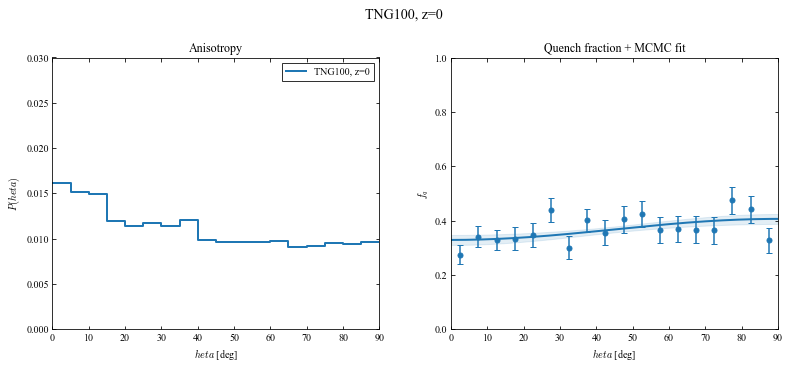

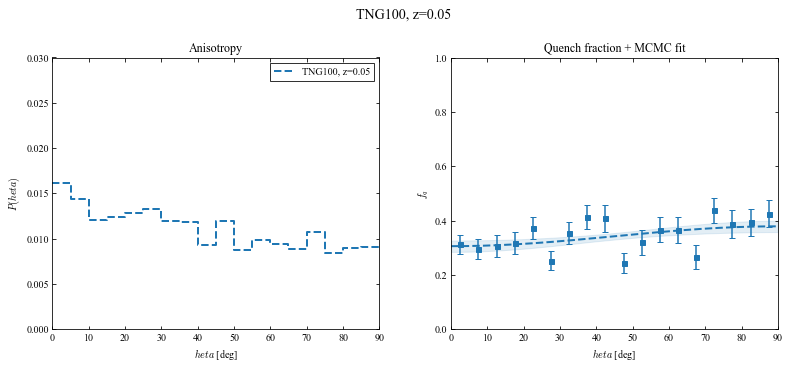

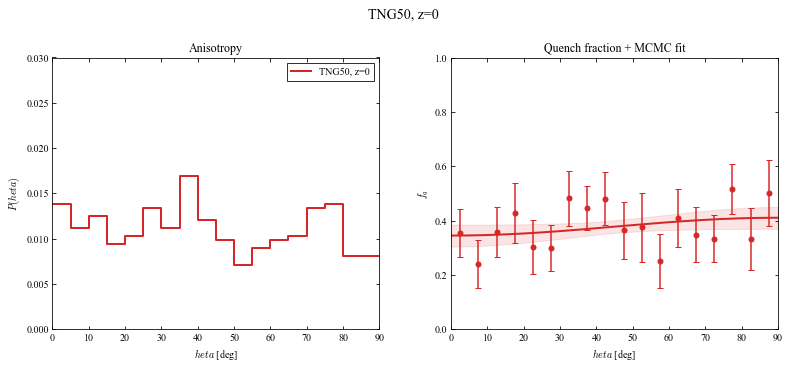

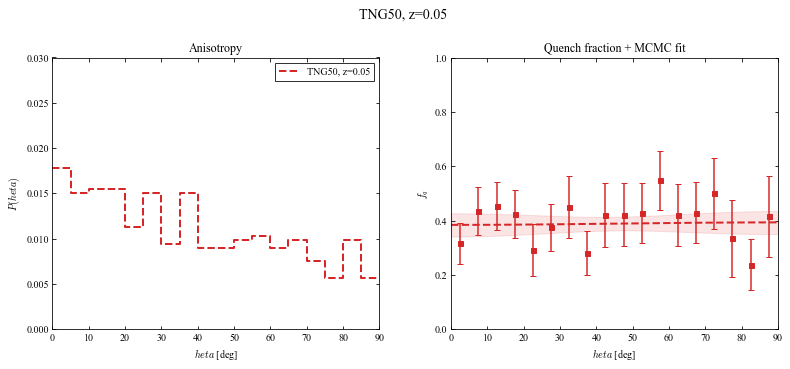

In [6]:
for label in data:
    plot_panels([label], title=label)

## 2. TNG100 and TNG50 separately (both redshifts overlaid)

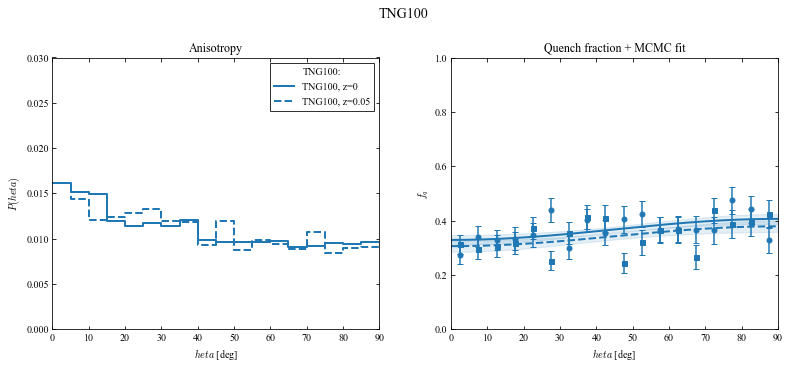

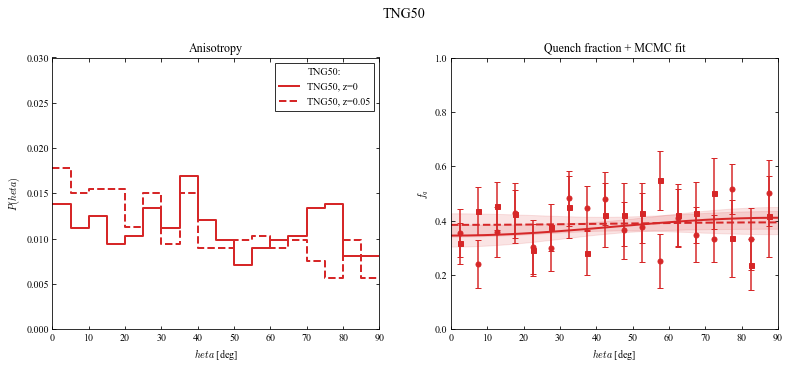

In [7]:
plot_panels(["TNG100, z=0", "TNG100, z=0.05"], title="TNG100", legend_title="TNG100:")
plot_panels(["TNG50, z=0",  "TNG50, z=0.05"],  title="TNG50",  legend_title="TNG50:")

## 3. Everything together

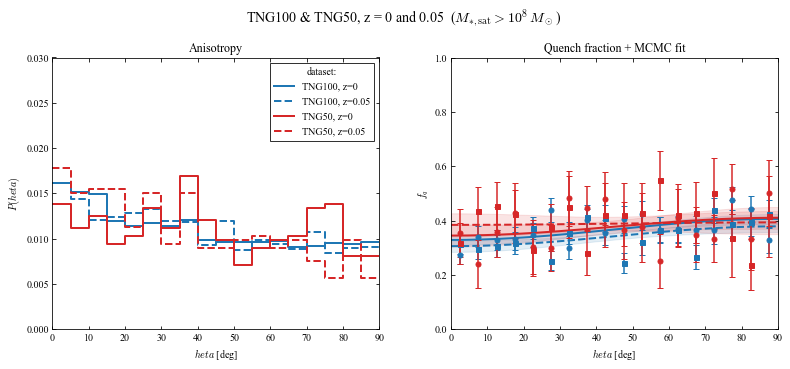

In [8]:
plot_panels(list(data), title="TNG100 & TNG50, z = 0 and 0.05  ($M_{*,\\rm sat} > 10^8\\,M_\\odot$)",
            legend_title="dataset:")